# AI-Generated Image Detection — Getting Started

## Problem

With the rise of generative models (Midjourney, DALL-E, Stable Diffusion, etc.), some sellers on e-commerce platforms have begun using AI-generated images to misrepresent product listings. This project, conducted in partnership with a major online marketplace under NDA, tackles the challenge of automatically detecting such images.

**Task:** Binary classification — given a listing image, predict:
- `1` → AI-generated
- `0` → Authentic

**Metric:** F1 score on a hidden test set.

---

**Data (in Google Drive):**
- `train.csv` — columns: `image_id`, `ground_truth`
- `test.csv`  — column: `image_id` (no labels)
- `genai_image_challenge.zip` — all images; filename = image_id

---

> **Environment note**  
> This notebook is written for **Google Colab**, which gives you free GPU/CPU, easy Google Drive access, and zero local setup. That said, every cell is plain Python and will run fine on any machine (local Jupyter, VS Code, Kaggle, etc.) — you just need to adjust the file paths in **Section 2** to point to wherever you store the data.

---

This notebook walks through a minimal working baseline:
1. Mount Google Drive and unzip the images
2. Load and explore the training data
3. Train/validation split
4. Extract simple features and train a classifier
5. Run inference on the test set and save predictions

## 0. Install Dependencies

In [1]:
!pip install scikit-learn opencv-python tqdm -q

## 1. Mount Google Drive

The data lives in **Shared with me → DCU 2026 ML challenge**.  
Before running: right-click the folder in Drive → **Organise → Add shortcut → My Drive**.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Unzip the Images

In [4]:
import zipfile, os

CHALLENGE_DIR = "/content/drive/MyDrive/DCU 2026 ML Challenge"
ZIP_PATH      = os.path.join(CHALLENGE_DIR, "genai_image_challenge.zip")
IMAGES_DIR    = "/content/images"   # extracted here (fast local SSD, not Drive)

if not os.path.exists(IMAGES_DIR):
    print("Extracting images...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    print(f"Done — extracted to {IMAGES_DIR}")
else:
    print(f"Already extracted: {IMAGES_DIR}")

# Peek at what's inside
sample_files = os.listdir(IMAGES_DIR)[:5]
print(f"Total images : {len(os.listdir(os.path.join(IMAGES_DIR,"images_final_sample")))}")
print(f"Sample names : {sample_files}")
IMAGES_DIR = os.path.join(IMAGES_DIR,"images_final_sample")

Extracting images...
Done — extracted to /content/images
Total images : 6858
Sample names : ['images_final_sample']


## 3. Load the Training Data

In [5]:
import pandas as pd

train_df = pd.read_csv(os.path.join(CHALLENGE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(CHALLENGE_DIR, "test.csv"))

# Map image_id → full path
def img_path(image_id):
    # Try common extensions; adjust if your images have a fixed extension
    for ext in ["", ".jpg", ".jpeg", ".png", ".webp"]:
        p = os.path.join(IMAGES_DIR, f"{image_id}{ext}")
        if os.path.exists(p):
            return p
    return None

train_df["path"] = train_df["image_id"].apply(img_path)
test_df["path"]  = test_df["image_id"].apply(img_path)

print(f"Train rows   : {len(train_df)}")
print(f"Test  rows   : {len(test_df)}")
print("\nLabel distribution:")
print(train_df["ground_truth"].value_counts().rename({0: "authentic", 1: "ai_generated"}))


Train rows   : 4800
Test  rows   : 2058

Label distribution:
ground_truth
authentic       2485
ai_generated    2315
Name: count, dtype: int64


## 4. Train / Validation Split

In [6]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ground_truth"]
)

print(f"Train : {len(train_split)} samples")
print(f"Val   : {len(val_split)} samples")

Train : 3840 samples
Val   : 960 samples


## 5. Feature Extraction


For this baseline we simply flatten each image into a 1D vector of pixel values.  
Try various feature extraction techniques — there is plenty of room to improve!

In [ ]:
import cv2
from tqdm import tqdm
import numpy as np
from PIL import Image

IMG_SIZE = (32, 32)  # small size to keep things fast

def extract_features(path: str) -> np.ndarray:
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        return np.array(img).flatten().astype(np.float32) / 255.0
    except Exception:
        return np.zeros(IMG_SIZE[0] * IMG_SIZE[1] * 3, dtype=np.float32)


def build_matrix(df, label_col=None):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(extract_features(row["path"]))
        if label_col:
            y.append(row[label_col])
    return np.array(X), np.array(y) if label_col else np.array(X)


print("Extracting train features...")
X_train, y_train = build_matrix(train_split, label_col="ground_truth")

print("Extracting val features...")
X_val, y_val = build_matrix(val_split, label_col="ground_truth")

print(f"Feature shape: {X_train.shape}")

Extracting train features...


100%|██████████| 3840/3840 [01:19<00:00, 48.07it/s]


Extracting val features...


100%|██████████| 960/960 [00:21<00:00, 44.99it/s]

Feature shape: (3840, 3072)


## 6. Train a Baseline Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluate on Validation Set

              precision    recall  f1-score   support

   Authentic       0.65      0.69      0.67       497
AI-Generated       0.64      0.60      0.62       463

    accuracy                           0.65       960
   macro avg       0.65      0.65      0.65       960
weighted avg       0.65      0.65      0.65       960

Precision : 0.6422
Recall    : 0.6048
F1 Score  : 0.6229


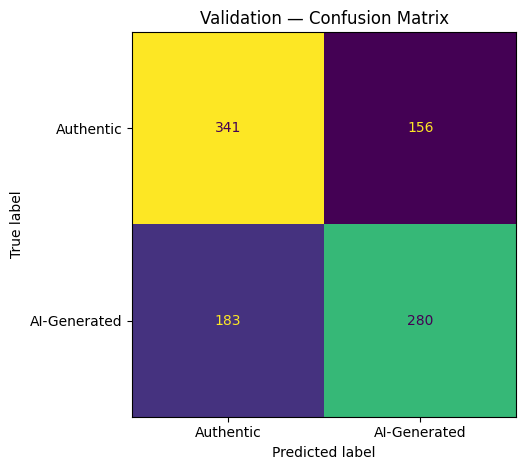

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix")
plt.tight_layout()
plt.show()

# Advanced Feature Extraction

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

In [ ]:
import cv2
from sklearn.ensemble import HistGradientBoostingClassifier

# Increased slightly from 32x32 to 64x64 to ensure the edge detector has enough detail to work with
IMG_SIZE = (64, 64)

def extract_advanced_features(path: str) -> np.ndarray:
    try:
        # 1. Load image with OpenCV (reads as BGR format)
        img = cv2.imread(path)
        if img is None:
            raise ValueError("Image not found or corrupted")

        img_resized = cv2.resize(img, IMG_SIZE)

        # 2. Convert to YCrCb (Great for finding AI color anomalies)
        ycrcb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)
        ycrcb_features = ycrcb.flatten()

        # 3. Sobel Edge Detection (Finds texture anomalies)
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel_features = np.sqrt(sobel_x**2 + sobel_y**2).flatten()

        # 4. Color Histograms (Global color statistics)
        hist_features = []
        for i in range(3):
            hist = cv2.calcHist([img_resized], [i], None, [256], [0, 256])
            hist_features.extend(hist.flatten())

        # Combine everything into one massive 1D feature vector
        combined_features = np.concatenate([
            ycrcb_features,
            sobel_features,
            hist_features
        ])

        return combined_features.astype(np.float32)

    except Exception:
        # If an image fails, return a zero-array of the exact right size so the matrix doesn't break
        expected_length = (IMG_SIZE[0] * IMG_SIZE[1] * 3) + (IMG_SIZE[0] * IMG_SIZE[1]) + (256 * 3)
        return np.zeros(expected_length, dtype=np.float32)
print("Advanced Extractor")

Advanced Extractor


 # Model 1 (Gradient Boosting)

In [ ]:
# --- MODEL 1: Histogram Gradient Boosting ---
# We use max_iter=200 (like 200 trees) and l2_regularization to prevent overfitting
gb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        l2_regularization=1.5,
        random_state=42
    ))
])

gradientBoosting_model = gb_model.fit(X_train, y_train)
print("Gradient Boosting Model Ready.")

Gradient Boosting Model Ready.


# Evaluating the Gradient Boosting model

              precision    recall  f1-score   support

   Authentic       0.67      0.70      0.68       497
AI-Generated       0.66      0.63      0.64       463

    accuracy                           0.66       960
   macro avg       0.66      0.66      0.66       960
weighted avg       0.66      0.66      0.66       960

Precision : 0.6599
Recall    : 0.6285
F1 Score  : 0.6438


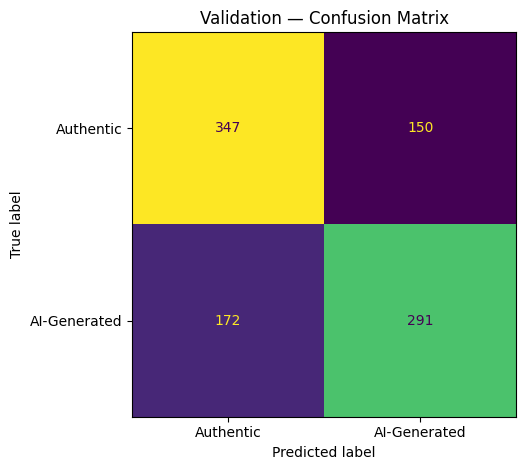

In [ ]:
y_pred = gradientBoosting_model.predict(X_val)

print(classification_report(y_val, y_pred, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix")
plt.tight_layout()
plt.show()

# Model 2 (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# --- MODEL 2: Support Vector Machine (with PCA) ---
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    # Compress the massive feature vector down to the top 100 most important patterns
    ("pca", PCA(n_components=100, random_state=42)),
    # The RBF kernel allows the model to draw curved, complex boundaries between Real and AI
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        class_weight="balanced", # Helps if you have more Real images than AI images, or vice versa
        probability=True,
        random_state=42
    ))
])

suppVec_model = svm_model.fit(X_train, y_train)
print("SVM with PCA pipeline is ready.")

SVM with PCA pipeline is ready.


# Evaluating Support Vector Machine model

              precision    recall  f1-score   support

   Authentic       0.67      0.65      0.66       497
AI-Generated       0.63      0.65      0.64       463

    accuracy                           0.65       960
   macro avg       0.65      0.65      0.65       960
weighted avg       0.65      0.65      0.65       960

Precision : 0.6324
Recall    : 0.6501
F1 Score  : 0.6411


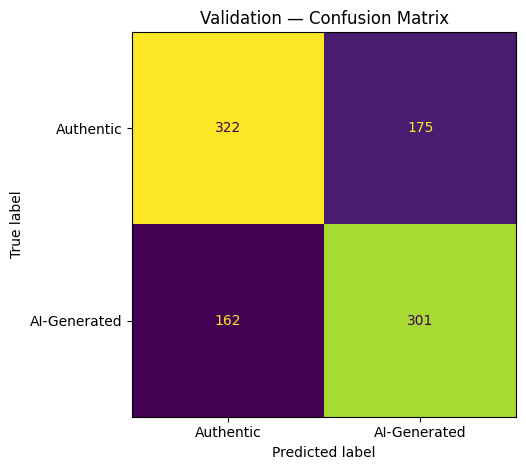

In [ ]:
y_pred = suppVec_model.predict(X_val)

print(classification_report(y_val, y_pred, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix")
plt.tight_layout()
plt.show()

# Model 3 (Random Forest using Advanced Features)

Training Random Forest...
Model trained. Generating predictions...
              precision    recall  f1-score   support

   Authentic       0.68      0.72      0.70       497
AI-Generated       0.68      0.63      0.65       463

    accuracy                           0.68       960
   macro avg       0.68      0.67      0.67       960
weighted avg       0.68      0.68      0.68       960

Precision : 0.6759
Recall    : 0.6307
F1 Score  : 0.6525


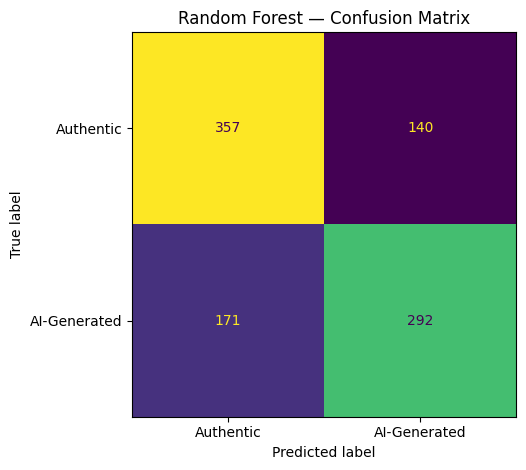

In [ ]:
# --- MODEL 3: Random Forest (Advanced Features) ---
randomForest_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200,       # Increased to 200 to match the Gradient Boosting model
        random_state=42,
        n_jobs=-1,              # CRITICAL: Uses all CPU cores to handle the 17,000+ features faster
        class_weight="balanced" # Helps balance if there's a slight unevenness in Real vs AI counts
    ))
])

print("Training Random Forest...")
rF_model = randomForest_model.fit(X_train, y_train)
print("Model trained. Generating predictions...")

# --- Evaluation ---
y_pred_rf = rF_model.predict(X_val)

print(classification_report(y_val, y_pred_rf, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred_rf):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_rf),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

# Deep Feature Extraction - using ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Load the pre-trained ResNet50 model
# include_top=False removes the final classification layer
# pooling='avg' flattens the output into a pure 1D array of 2048 numbers
print("Loading ResNet50 Model (this might take a few seconds)...")
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("Model Loaded!")

# ResNet50 specifically expects images to be 224x224 pixels
DEEP_IMG_SIZE = (224, 224)

def extract_deep_features(path: str) -> np.ndarray:
    try:
        # Load the image and resize it to ResNet's preferred size
        img = image.load_img(path, target_size=DEEP_IMG_SIZE)

        # Convert the image to a raw numerical array
        img_array = image.img_to_array(img)

        # Neural networks expect a "batch" of images.
        # We add a dummy dimension to make it shape (1, 224, 224, 3)
        img_batch = np.expand_dims(img_array, axis=0)

        # Apply ResNet's specific data normalization (mean centering, color channel shifting)
        processed_image = preprocess_input(img_batch)

        # Pass the image through the 50-layer neural network
        # verbose=0 stops it from printing a progress bar for every single image
        deep_features = resnet_model.predict(processed_image, verbose=0)

        # Return the 2048 deep features
        return deep_features.flatten()

    except Exception:
        # If an image is broken, return a blank slate of 2048 zeros
        return np.zeros(2048, dtype=np.float32)

Loading ResNet50 Model (this might take a few seconds)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model Loaded!


In [ ]:
import cv2
from tqdm import tqdm
import numpy as np
from PIL import Image

def build_matrix(df, label_col=None):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(extract_deep_features(row["path"]))
        if label_col:
            y.append(row[label_col])
    return np.array(X), np.array(y) if label_col else np.array(X)


print("Extracting train features...")
X_train, y_train = build_matrix(train_split, label_col="ground_truth")

print("Extracting val features...")
X_val, y_val = build_matrix(val_split, label_col="ground_truth")

print(f"Feature shape: {X_train.shape}")

Extracting train features...


100%|██████████| 3840/3840 [23:19<00:00,  2.74it/s]


Extracting val features...


100%|██████████| 960/960 [05:51<00:00,  2.73it/s]

Feature shape: (3840, 2048)


# DEEP HYBRID MODEL: Random Forest

Training Deep Hybrid Random Forest...
Model trained. Generating predictions...
              precision    recall  f1-score   support

   Authentic       0.76      0.83      0.79       497
AI-Generated       0.80      0.71      0.75       463

    accuracy                           0.78       960
   macro avg       0.78      0.77      0.77       960
weighted avg       0.78      0.78      0.77       960

Precision : 0.7976
Recall    : 0.7149
F1 Score  : 0.7540


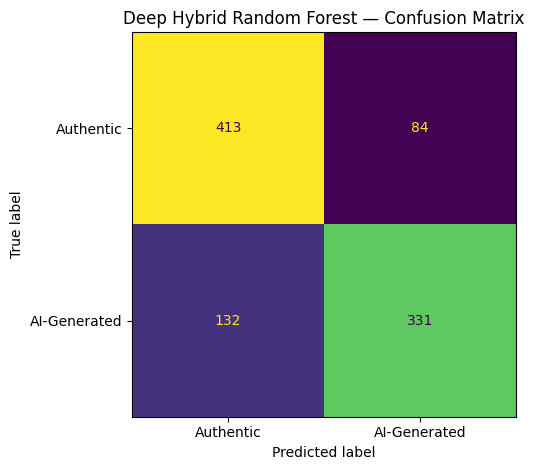

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- DEEP HYBRID MODEL: Random Forest ---
# We use the same parameters as before so it's a fair "apples-to-apples" comparison
deep_rf_model = Pipeline([
    # Standard scaling is still good practice to normalize the embeddings
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

print("Training Deep Hybrid Random Forest...")
deep_rf_model.fit(X_train, y_train)
print("Model trained. Generating predictions...")

# --- Evaluation ---
y_pred_deep_rf = deep_rf_model.predict(X_val)

print(classification_report(y_val, y_pred_deep_rf, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred_deep_rf):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_deep_rf):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred_deep_rf):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_deep_rf),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Deep Hybrid Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

# DEEP HYBRID MODEL: Gradient Boosting

Training Deep Hybrid Gradient Boosting...
Model trained. Generating predictions...
--- Deep Gradient Boosting Results ---
              precision    recall  f1-score   support

   Authentic       0.79      0.83      0.81       497
AI-Generated       0.81      0.76      0.78       463

    accuracy                           0.79       960
   macro avg       0.80      0.79      0.79       960
weighted avg       0.80      0.79      0.79       960

Precision : 0.8050
Recall    : 0.7581
F1 Score  : 0.7809


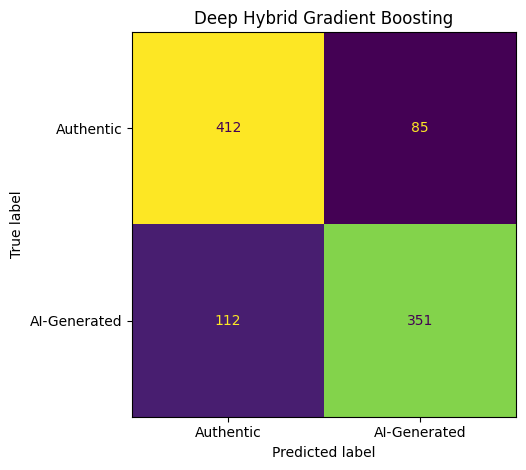

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# --- DEEP HYBRID MODEL: Gradient Boosting ---
deep_gb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        l2_regularization=1.5,
        random_state=42
    ))
])

print("Training Deep Hybrid Gradient Boosting...")
deep_gb_model.fit(X_train, y_train)
print("Model trained. Generating predictions...")

# --- Evaluation ---
y_pred_deep_gb = deep_gb_model.predict(X_val)

print("--- Deep Gradient Boosting Results ---")
print(classification_report(y_val, y_pred_deep_gb, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred_deep_gb):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_deep_gb):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred_deep_gb):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_deep_gb),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Deep Hybrid Gradient Boosting")
plt.tight_layout()
plt.show()

# DEEP HYBRID MODEL: Support Vector Machine (BEST uptil now)

Training Deep Hybrid SVM...
Model trained. Generating predictions...
--- Deep SVM Results ---
              precision    recall  f1-score   support

   Authentic       0.82      0.83      0.83       497
AI-Generated       0.82      0.81      0.81       463

    accuracy                           0.82       960
   macro avg       0.82      0.82      0.82       960
weighted avg       0.82      0.82      0.82       960

Precision : 0.8170
Recall    : 0.8099
F1 Score  : 0.8134


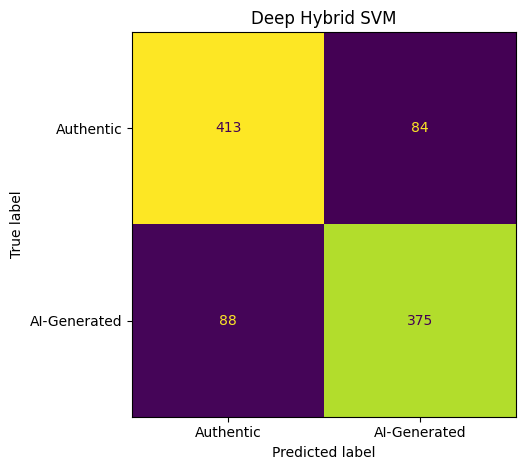

In [ ]:
from sklearn.svm import SVC

# --- DEEP HYBRID MODEL: Support Vector Machine ---
deep_svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

print("Training Deep Hybrid SVM...")
deep_svm_model.fit(X_train, y_train)
print("Model trained. Generating predictions...")

# --- Evaluation ---
y_pred_deep_svm = deep_svm_model.predict(X_val)

print("--- Deep SVM Results ---")
print(classification_report(y_val, y_pred_deep_svm, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred_deep_svm):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_deep_svm):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred_deep_svm):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_deep_svm),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Deep Hybrid SVM")
plt.tight_layout()
plt.show()

## Ensemble combining EfficientNetV2-S with an FFT frequency branch, ConvNeXt-Small, and ConvNeXt-Base, trained with Focal Loss, Mixup augmentation, Stochastic Weight Averaging (SWA), and 5-view Test-Time Augmentation

In [7]:
!pip install timm --quiet

import zipfile, os, random, warnings
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [12]:
IMG_SIZE    = 384
BATCH_SIZE  = 16    # reduce to 8 if ConvNeXt-Base causes OOM
NUM_EPOCHS  = 16
SWA_START   = 14    # start averaging weights from this epoch onward
BACKBONE_LR = 2e-5
HEAD_LR     = 1e-4
FFT_SIZE    = 64

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
NUM_WORKERS = 2

In [13]:
class JPEGCompression:
    def __init__(self, quality_range=(40, 90)):
        self.low, self.high = quality_range
    def __call__(self, img):
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=random.randint(self.low, self.high))
        buf.seek(0)
        return Image.open(buf).convert('RGB')

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomApply([JPEGCompression(quality_range=(40, 85))], p=0.5),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=7),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
]

class ImageDataset(Dataset):
    def __init__(self, df, transform, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.transform  = transform
        self.has_labels = has_labels
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.transform(Image.open(row['path']).convert('RGB'))
        if self.has_labels:
            return img, torch.tensor(row['ground_truth'], dtype=torch.float32)
        return img

def make_loader(df, tfm, has_labels=True, shuffle=False):
    return DataLoader(
        ImageDataset(df, tfm, has_labels),
        batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=True
    )

train_loader = make_loader(train_split, train_transform, shuffle=True)
val_loader   = make_loader(val_split,   val_transform)
print('Data loaders ready')

Data loaders ready


In [14]:
class FFTBranch(nn.Module):
    def __init__(self, fft_size=64, out_dim=128):
        super().__init__()
        self.fft_size = fft_size
        self.fc = nn.Sequential(
            nn.Linear(fft_size * fft_size, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, out_dim), nn.ReLU(),
        )
    def forward(self, x):
        gray = x.mean(dim=1, keepdim=True)
        mag  = torch.log1p(torch.abs(torch.fft.fft2(gray.squeeze(1)))).unsqueeze(1)
        mag  = F.interpolate(mag, size=(self.fft_size, self.fft_size),
                             mode='bilinear', align_corners=False).squeeze(1)
        return self.fc(mag.flatten(1))


def make_head(in_dim, dropout=0.4):
    return nn.Sequential(
        nn.Dropout(dropout), nn.Linear(in_dim, 256), nn.ReLU(),
        nn.Dropout(dropout / 2), nn.Linear(256, 1)
    )


class ModelA(nn.Module):
    """EfficientNetV2-S + FFT branch (from v2/v3)"""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s', pretrained=True, num_classes=0, global_pool='avg')
        self.fft  = FFTBranch(FFT_SIZE, 128)
        self.head = make_head(self.backbone.num_features + 128)
    def forward(self, x):
        return self.head(torch.cat([self.backbone(x), self.fft(x)], dim=1)).squeeze(1)


class ModelB(nn.Module):
    """ConvNeXt-Small (from v3)"""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_small', pretrained=True, num_classes=0, global_pool='avg')
        self.head = make_head(self.backbone.num_features)
    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


class ModelC(nn.Module):
    """
    ConvNeXt-Base — new in v4.
    ~89M parameters vs ~50M for Small.
    Stronger at detecting subtle texture and edge inconsistencies.
    If you hit GPU OOM, reduce BATCH_SIZE to 8 for this model only.
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_base', pretrained=True, num_classes=0, global_pool='avg')
        self.head = make_head(self.backbone.num_features)
    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


model_a = ModelA().to(DEVICE)
model_b = ModelB().to(DEVICE)
model_c = ModelC().to(DEVICE)

for name, m in [('A (EffNetV2-S+FFT)', model_a),
                ('B (ConvNeXt-Small)', model_b),
                ('C (ConvNeXt-Base) ', model_c)]:
    p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    print(f'Model {name}: {p/1e6:.1f}M params')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Model A (EffNetV2-S+FFT): 21.6M params
Model B (ConvNeXt-Small): 49.7M params
Model C (ConvNeXt-Base) : 87.8M params


In [15]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        return (((1 - torch.exp(-bce)) ** self.gamma) * bce).mean()


def mixup_batch(imgs, labels, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam * imgs + (1-lam) * imgs[idx], lam * labels + (1-lam) * labels[idx]


def find_best_threshold(probs, labels):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.20, 0.81, 0.01):
        f = f1_score(labels, (probs >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return round(best_t, 2), round(best_f1, 4)


def train_one_model(model, save_path, label, batch_size_override=None):
    """
    Trains model with:
    - Focal Loss + class weighting
    - Two-speed LR (backbone slow, head fast)
    - Mixup augmentation
    - SWA from epoch SWA_START onward
    - Saves best checkpoint AND SWA checkpoint
    """
    # Allow per-model batch size (ConvNeXt-Base may need smaller)
    t_loader = train_loader
    v_loader = val_loader
    if batch_size_override:
        t_loader = make_loader(train_split, train_transform,
                               shuffle=True)
        # rebuild with override — DataLoader doesn't allow changing batch_size in-place
        t_loader = DataLoader(
            ImageDataset(train_split, train_transform),
            batch_size=batch_size_override, shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=True
        )

    n_pos = (train_split['ground_truth'] == 1).sum()
    n_neg = (train_split['ground_truth'] == 0).sum()
    pos_w = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(gamma=2.0, pos_weight=pos_w)

    # Build param groups: backbone gets slow LR, everything else gets fast LR
    slow_params = list(model.backbone.parameters())
    fast_params = [p for n, p in model.named_parameters()
                   if not n.startswith('backbone')]
    optimizer = torch.optim.AdamW([
        {'params': slow_params, 'lr': BACKBONE_LR},
        {'params': fast_params, 'lr': HEAD_LR},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[BACKBONE_LR, HEAD_LR],
        steps_per_epoch=len(t_loader),
        epochs=NUM_EPOCHS, pct_start=0.1,
    )

    # SWA setup
    # AveragedModel keeps a running average of the model's weights
    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(optimizer, swa_lr=1e-5)  # constant low LR during SWA phase

    scaler   = torch.cuda.amp.GradScaler()
    best_f1  = 0.0
    best_thresh = 0.5

    print(f'\n=== Training {label} ===')

    for epoch in range(1, NUM_EPOCHS + 1):
        in_swa_phase = (epoch >= SWA_START)

        # ── Train ──────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(t_loader, desc=f'Ep {epoch:02d}/{NUM_EPOCHS} train'):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if random.random() < 0.5:
                imgs, labels = mixup_batch(imgs, labels)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            # During SWA phase, use SWA scheduler instead of OneCycleLR
            if not in_swa_phase:
                scheduler.step()

            running_loss += loss.item()

        # After each SWA-phase epoch, update the SWA model and scheduler
        if in_swa_phase:
            swa_model.update_parameters(model)
            swa_scheduler.step()

        avg_loss = running_loss / len(t_loader)

        # ── Validate (using the regular model, not SWA model yet) ──────
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for imgs, labs in tqdm(v_loader, desc=f'Ep {epoch:02d}/{NUM_EPOCHS} val  '):
                with torch.cuda.amp.autocast():
                    probs = torch.sigmoid(model(imgs.to(DEVICE)))
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labs.numpy())

        thresh, val_f1 = find_best_threshold(np.array(all_probs), np.array(all_labels))
        swa_marker = ' [SWA]' if in_swa_phase else ''
        print(f'Epoch {epoch:02d}  loss={avg_loss:.4f}  val_F1={val_f1:.4f}  '
              f'threshold={thresh}{swa_marker}')

        if val_f1 > best_f1:
            best_f1, best_thresh = val_f1, thresh
            torch.save(model.state_dict(), save_path)
            print(f'  -> New best ({label} F1={best_f1:.4f})')

    # ── Finalise SWA: update BatchNorm statistics ───────────────────────
    # SWA averages weights but BN running stats need to be recalculated
    print('Updating SWA BatchNorm stats...')
    update_bn(t_loader, swa_model, device=DEVICE)
    torch.save(swa_model.state_dict(), save_path.replace('.pt', '_swa.pt'))

    # ── Evaluate SWA model on validation ────────────────────────────────
    swa_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labs in v_loader:
            with torch.cuda.amp.autocast():
                probs = torch.sigmoid(swa_model(imgs.to(DEVICE)))
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labs.numpy())

    swa_thresh, swa_f1 = find_best_threshold(np.array(all_probs), np.array(all_labels))
    print(f'SWA model F1: {swa_f1:.4f}  (regular best: {best_f1:.4f})')

    # Use whichever is better: regular checkpoint or SWA
    if swa_f1 > best_f1:
        best_f1, best_thresh = swa_f1, swa_thresh
        # Copy SWA weights back to regular model for uniform inference
        model.load_state_dict(
            {k.replace('module.', ''): v
             for k, v in swa_model.state_dict().items()}
        )
        torch.save(model.state_dict(), save_path)
        print(f'  -> SWA was better! Using SWA weights.')

    print(f'\n{label} final F1: {best_f1:.4f}  threshold: {best_thresh}')
    return best_f1, best_thresh

In [19]:
!pip install timm --quiet

import zipfile, os, random, io
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from tqdm import tqdm
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn


f1_a, thresh_a = train_one_model(model_a, 'best_model_a.pt', 'Model A (EffNetV2-S+FFT)')


=== Training Model A (EffNetV2-S+FFT) ===


Ep 01/16 val  : 100%|██████████| 60/60 [00:17<00:00,  3.41it/s]


Epoch 01  loss=0.1860  val_F1=0.7664  threshold=0.56
  -> New best (Model A (EffNetV2-S+FFT) F1=0.7664)


Ep 02/16 val  : 100%|██████████| 60/60 [00:17<00:00,  3.42it/s]


Epoch 02  loss=0.1472  val_F1=0.8403  threshold=0.53
  -> New best (Model A (EffNetV2-S+FFT) F1=0.8403)


...

Epoch 14  loss=0.0648  val_F1=0.8882  threshold=0.64 [SWA]


Ep 15/16 val  : 100%|██████████| 60/60 [00:17<00:00,  3.45it/s]


Epoch 15  loss=0.0680  val_F1=0.8826  threshold=0.68 [SWA]


Ep 16/16 val  : 100%|██████████| 60/60 [00:17<00:00,  3.36it/s]


Epoch 16  loss=0.0647  val_F1=0.8875  threshold=0.62 [SWA]
Updating SWA BatchNorm stats...
SWA model F1: 0.8875  (regular best: 0.8930)

Model A (EffNetV2-S+FFT) final F1: 0.8930  threshold: 0.63


In [21]:
f1_b, thresh_b = train_one_model(model_b, 'best_model_b.pt', 'Model B (ConvNeXt-Small)')


=== Training Model B (ConvNeXt-Small) ===


Ep 01/16 val  : 100%|██████████| 60/60 [00:19<00:00,  3.04it/s]


Epoch 01  loss=0.0263  val_F1=0.8963  threshold=0.68
  -> New best (Model B (ConvNeXt-Small) F1=0.8963)


Ep 02/16 val  : 100%|██████████| 60/60 [00:18<00:00,  3.25it/s]


Epoch 02  loss=0.0517  val_F1=0.8866  threshold=0.73


...

Epoch 14  loss=0.0240  val_F1=0.9070  threshold=0.77 [SWA]


Ep 15/16 val  : 100%|██████████| 60/60 [00:18<00:00,  3.26it/s]


Epoch 15  loss=0.0174  val_F1=0.9113  threshold=0.81 [SWA]
  -> New best (Model B (ConvNeXt-Small) F1=0.9113)


Ep 16/16 val  : 100%|██████████| 60/60 [00:18<00:00,  3.20it/s]


Epoch 16  loss=0.0176  val_F1=0.9201  threshold=0.63 [SWA]
  -> New best (Model B (ConvNeXt-Small) F1=0.9201)
Updating SWA BatchNorm stats...
SWA model F1: 0.9166  (regular best: 0.9201)

Model B (ConvNeXt-Small) final F1: 0.9201  threshold: 0.63


In [22]:
# ConvNeXt-Base is larger — reduce batch size to 8 if you see CUDA OOM error
f1_c, thresh_c = train_one_model(model_c, 'best_model_c.pt', 'Model C (ConvNeXt-Base)',
                                  batch_size_override=8)


=== Training Model C (ConvNeXt-Base) ===


Ep 01/16 val  : 100%|██████████| 60/60 [00:26<00:00,  2.26it/s]


Epoch 01  loss=0.1837  val_F1=0.7912  threshold=0.52
  -> New best (Model C (ConvNeXt-Base) F1=0.7912)


Ep 02/16 val  : 100%|██████████| 60/60 [00:19<00:00,  3.11it/s]


Epoch 02  loss=0.1297  val_F1=0.8677  threshold=0.59
  -> New best (Model C (ConvNeXt-Base) F1=0.8677)


...

Epoch 14  loss=0.0235  val_F1=0.9308  threshold=0.78 [SWA]


Ep 15/16 val  : 100%|██████████| 60/60 [00:20<00:00,  2.91it/s]


Epoch 15  loss=0.0216  val_F1=0.9293  threshold=0.76 [SWA]


Ep 16/16 val  : 100%|██████████| 60/60 [00:20<00:00,  2.87it/s]


Epoch 16  loss=0.0231  val_F1=0.9267  threshold=0.77 [SWA]
Updating SWA BatchNorm stats...
SWA model F1: 0.9277  (regular best: 0.9356)

Model C (ConvNeXt-Base) final F1: 0.9356  threshold: 0.44


In [23]:
@torch.no_grad()
def get_tta_probs(model, df, has_labels=False):
    """Run 5-view TTA, return averaged probabilities."""
    model.eval()
    all_views = []
    for tfm in tta_transforms:
        loader = make_loader(df, tfm, has_labels=has_labels)
        probs  = []
        for batch in loader:
            imgs = batch[0] if has_labels else batch
            with torch.cuda.amp.autocast():
                p = torch.sigmoid(model(imgs.to(DEVICE)))
            probs.extend(p.cpu().numpy())
        all_views.append(probs)
    return np.mean(all_views, axis=0)


# Load best checkpoints
for m, path in [(model_a, 'best_model_a.pt'),
                (model_b, 'best_model_b.pt'),
                (model_c, 'best_model_c.pt')]:
    m.load_state_dict(torch.load(path, weights_only=True))

val_labels = val_split['ground_truth'].values

print('Computing validation TTA probs...')
vp_a = get_tta_probs(model_a, val_split, has_labels=True)
vp_b = get_tta_probs(model_b, val_split, has_labels=True)
vp_c = get_tta_probs(model_c, val_split, has_labels=True)

# Strategy 1: Equal average
probs_eq = (vp_a + vp_b + vp_c) / 3
t_eq, f1_eq = find_best_threshold(probs_eq, val_labels)

# Strategy 2: Weighted by individual F1
total_f1 = f1_a + f1_b + f1_c
wa, wb, wc = f1_a/total_f1, f1_b/total_f1, f1_c/total_f1
probs_wt = wa*vp_a + wb*vp_b + wc*vp_c
t_wt, f1_wt = find_best_threshold(probs_wt, val_labels)

# Strategy 3: Rank-based weighting (softer — squares the weight difference)
# Gives ConvNeXt-Base even more influence if it's the best
scores = np.array([f1_a, f1_b, f1_c])
rank_w = scores ** 2 / (scores ** 2).sum()
probs_rk = rank_w[0]*vp_a + rank_w[1]*vp_b + rank_w[2]*vp_c
t_rk, f1_rk = find_best_threshold(probs_rk, val_labels)

print(f'\nModel A alone:         F1={f1_a:.4f}  threshold={thresh_a}')
print(f'Model B alone:         F1={f1_b:.4f}  threshold={thresh_b}')
print(f'Model C alone:         F1={f1_c:.4f}  threshold={thresh_c}')
print(f'Equal ensemble:        F1={f1_eq:.4f}  threshold={t_eq}')
print(f'Weighted ensemble:     F1={f1_wt:.4f}  threshold={t_wt}  '
      f'(w={wa:.2f}/{wb:.2f}/{wc:.2f})')
print(f'Rank-weighted ensemble:F1={f1_rk:.4f}  threshold={t_rk}')

# Pick the best strategy automatically
best_strategy = max(
    [('equal', f1_eq, probs_eq, t_eq),
     ('weighted', f1_wt, probs_wt, t_wt),
     ('rank', f1_rk, probs_rk, t_rk)],
    key=lambda x: x[1]
)
strategy_name, best_ensemble_f1, best_val_probs, best_thresh = best_strategy
print(f'\nBest strategy: {strategy_name} ensemble  F1={best_ensemble_f1:.4f}  '
      f'threshold={best_thresh}')

Computing validation TTA probs...

Model A alone:         F1=0.8930  threshold=0.63
Model B alone:         F1=0.9201  threshold=0.63
Model C alone:         F1=0.9356  threshold=0.44
Equal ensemble:        F1=0.9310  threshold=0.57
Weighted ensemble:     F1=0.9310  threshold=0.57  (w=0.32/0.33/0.34)
Rank-weighted ensemble:F1=0.9317  threshold=0.6

Best strategy: rank ensemble  F1=0.9317  threshold=0.6


## 8. Inference on Test Set

In [24]:
print('Running TTA on test set...')
tp_a = get_tta_probs(model_a, test_df)
tp_b = get_tta_probs(model_b, test_df)
tp_c = get_tta_probs(model_c, test_df)

if strategy_name == 'equal':
    test_probs = (tp_a + tp_b + tp_c) / 3
elif strategy_name == 'weighted':
    test_probs = wa*tp_a + wb*tp_b + wc*tp_c
else:
    test_probs = rank_w[0]*tp_a + rank_w[1]*tp_b + rank_w[2]*tp_c

test_df["prediction"] = (test_probs >= best_thresh).astype(int)

print("Prediction distribution:")
print(test_df["prediction"].value_counts().rename({0: "authentic", 1: "ai_generated"}))

submission = test_df[["image_id", "prediction"]]
submission.to_csv("submission.csv", index=False)
print("\nSaved → submission.csv")
submission.head()

Running TTA on test set...
Prediction distribution:
prediction
authentic       1125
ai_generated     933
Name: count, dtype: int64

Saved → submission.csv


,image_id,prediction
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,0
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,0
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,0
